In [2]:
from google.colab import files
uploaded = files.upload()

Saving amazon_sales_dataset.csv to amazon_sales_dataset.csv


In [3]:
import pandas as pd

data = pd.read_csv("amazon_sales_dataset.csv")

data.head()

,order_id,order_date,ship_date,delivery_date,order_status,customer_id,customer_name,country,state,city,...,product_name,category,sub_category,brand,quantity,unit_price,discount,shipping_cost,total_sales,payment_method
0,A10000,2026-01-31,2026-01-31,2026-01-08,Delivered,C5691,Ricky Potter,India,South Carolina,New Joe,...,without,Home,Furniture,Doyle-Jordan,3,42467.79,0.26,60.85,94339.3438,Card
1,A10001,2026-01-20,2026-02-03,2026-02-03,Delivered,C9811,Chris Davenport,India,Tennessee,Madisonmouth,...,school,Home,Furniture,Davis LLC,2,36138.76,0.24,112.96,55043.8752,COD
2,A10002,2026-01-15,2026-02-07,2026-01-03,Delivered,C7341,Timothy Gallagher,India,Iowa,East Larryberg,...,I,Electronics,Laptop,Watson and Sons,4,47148.93,0.14,64.11,162256.4292,UPI
3,A10003,2026-01-18,2026-01-15,2026-01-20,Delivered,C4012,Angela Collins,India,Kentucky,South Margaretshire,...,step,Electronics,Laptop,"Sandoval, Buckley and Solis",1,18487.99,0.06,114.15,17492.8606,Card
4,A10004,2026-01-27,2026-01-04,2026-01-23,Delivered,C1328,David Davidson DDS,India,North Dakota,Velasquezview,...,bit,Home,Kitchen,"Key, Bautista and Bowen",1,1742.25,0.10,40.47,1608.4950,UPI


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        10000 non-null  object 
 1   order_date      10000 non-null  object 
 2   ship_date       10000 non-null  object 
 3   delivery_date   10000 non-null  object 
 4   order_status    10000 non-null  object 
 5   customer_id     10000 non-null  object 
 6   customer_name   10000 non-null  object 
 7   country         10000 non-null  object 
 8   state           10000 non-null  object 
 9   city            10000 non-null  object 
 10  product_id      10000 non-null  object 
 11  product_name    10000 non-null  object 
 12  category        10000 non-null  object 
 13  sub_category    10000 non-null  object 
 14  brand           10000 non-null  object 
 15  quantity        10000 non-null  int64  
 16  unit_price      10000 non-null  float64
 17  discount        10000 non-null  

In [5]:
data.describe()

,quantity,unit_price,discount,shipping_cost,total_sales
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,3.01440,25126.511133,0.149968,85.053192,64212.910555
std,1.42035,14343.922332,0.086828,37.575284,50992.635082
min,1.00000,214.200000,0.000000,20.010000,309.939600
25%,2.00000,12657.827500,0.070000,52.507500,24037.196775
50%,3.00000,24880.490000,0.150000,84.995000,50287.177500
75%,4.00000,37544.640000,0.220000,117.680000,93417.891825
max,5.00000,49981.880000,0.300000,149.950000,249155.530000


In [6]:
data.isnull().sum()

,0
order_id,0
order_date,0
ship_date,0
delivery_date,0
order_status,0
customer_id,0
customer_name,0
country,0
state,0
city,0


In [7]:
data['order_date'] = pd.to_datetime(data['order_date'])
data['ship_date'] = pd.to_datetime(data['ship_date'])
data['delivery_date'] = pd.to_datetime(data['delivery_date'])

In [8]:
data['total_sales'].sum()

np.float64(642129105.5516)

In [9]:
data.groupby('category')['total_sales'].sum()

,total_sales
category,
Electronics,2.193563e+08
Fashion,2.080091e+08
Home,2.147638e+08


In [10]:
data.groupby('product_name')['total_sales'].sum().sort_values(ascending=False).head(10)

,total_sales
product_name,
maintain,2.096518e+06
include,1.930786e+06
trouble,1.711159e+06
suffer,1.629241e+06
will,1.590366e+06
trade,1.539003e+06
big,1.470008e+06
cut,1.466105e+06
many,1.450177e+06


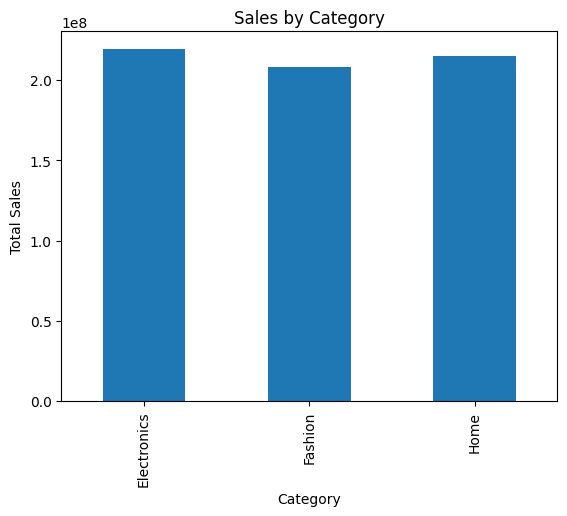

In [11]:
import matplotlib.pyplot as plt

data.groupby('category')['total_sales'].sum().plot(kind='bar')

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

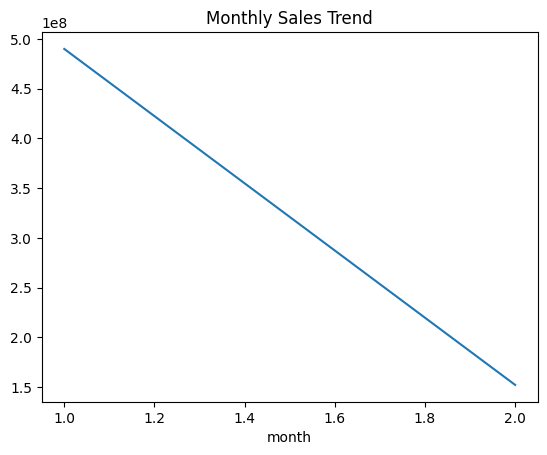

In [12]:
data['month'] = data['order_date'].dt.month

monthly_sales = data.groupby('month')['total_sales'].sum()

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.show()

In [13]:
top_products = data.groupby('product_name')['total_sales'].sum().sort_values(ascending=False).head(10)

print(top_products)

product_name
maintain    2.096518e+06
include     1.930786e+06
trouble     1.711159e+06
suffer      1.629241e+06
will        1.590366e+06
trade       1.539003e+06
big         1.470008e+06
cut         1.466105e+06
many        1.450177e+06
level       1.404670e+06
Name: total_sales, dtype: float64


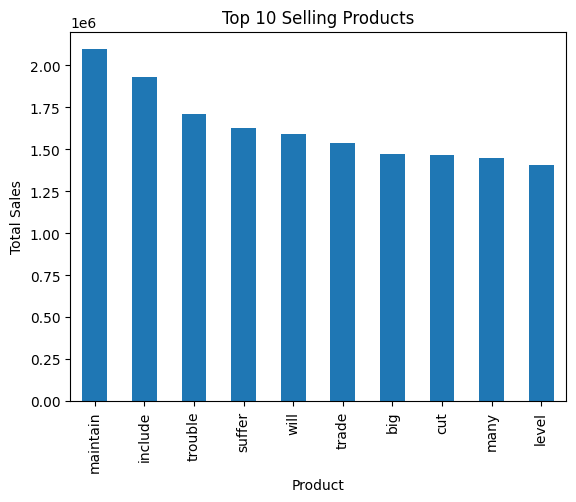

In [14]:
top_products.plot(kind='bar')

plt.title("Top 10 Selling Products")
plt.xlabel("Product")
plt.ylabel("Total Sales")

plt.show()

In [15]:
category_sales = data.groupby('category')['total_sales'].sum()

print(category_sales)

category
Electronics    2.193563e+08
Fashion        2.080091e+08
Home           2.147638e+08
Name: total_sales, dtype: float64


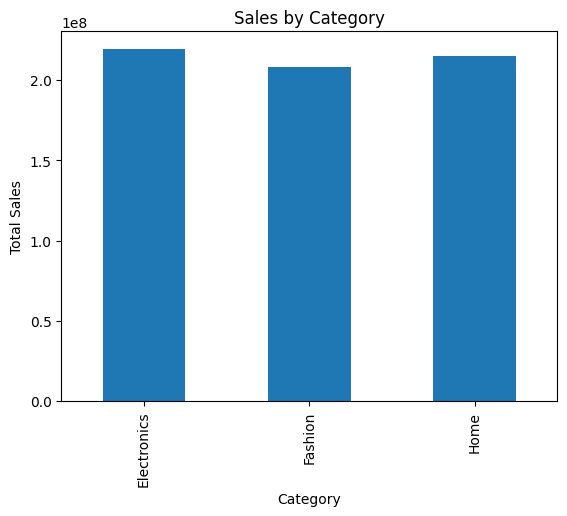

In [16]:
category_sales.plot(kind='bar')

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

In [17]:
payment_sales = data.groupby('payment_method')['total_sales'].sum()

print(payment_sales)

payment_method
COD           1.637298e+08
Card          1.612822e+08
NetBanking    1.582953e+08
UPI           1.588218e+08
Name: total_sales, dtype: float64


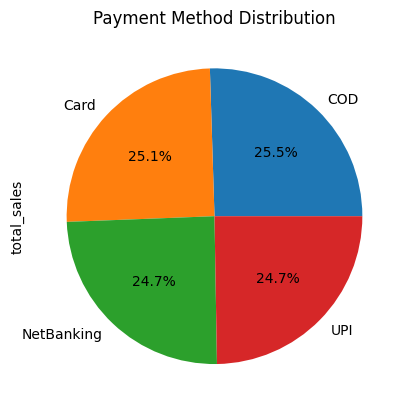

In [19]:
payment_sales.plot(kind='pie', autopct='%1.1f%%')

plt.title("Payment Method Distribution")

plt.show()

In [20]:
state_sales = data.groupby('state')['total_sales'].sum().sort_values(ascending=False)

print(state_sales.head(10))

state
North Carolina    1.503767e+07
Arizona           1.470989e+07
Oklahoma          1.437737e+07
North Dakota      1.434795e+07
New Mexico        1.425520e+07
Arkansas          1.420703e+07
Connecticut       1.410674e+07
Washington        1.408091e+07
Idaho             1.390459e+07
Massachusetts     1.388731e+07
Name: total_sales, dtype: float64


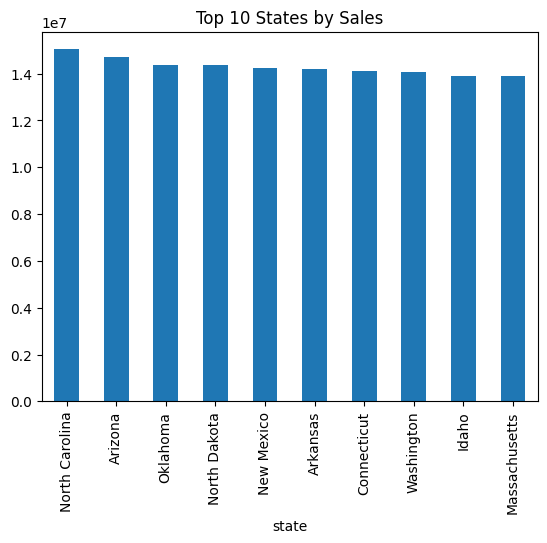

In [21]:
state_sales.head(10).plot(kind='bar')

plt.title("Top 10 States by Sales")

plt.show()

In [22]:
brand_sales = data.groupby('brand')['total_sales'].sum().sort_values(ascending=False)

print(brand_sales.head(10))

brand
Johnson and Sons     1.185207e+06
Smith Ltd            1.178539e+06
Smith and Sons       1.011521e+06
Jones and Sons       9.963234e+05
Martinez and Sons    9.575483e+05
Williams LLC         9.150102e+05
Smith LLC            9.045955e+05
Jones Inc            8.635709e+05
Martinez PLC         8.158866e+05
Brown Group          7.974931e+05
Name: total_sales, dtype: float64


Johnson and Sons generated the highest revenue with approximately 1.18 million in total sales, making it the top-performing brand.

Smith Ltd and Smith and Sons are also strong contributors, indicating that the Smith brand group dominates overall sales performance.

The top 10 brands together contribute a significant portion of total revenue, showing that sales are concentrated among a few high-performing brands.

Sales distribution across brands suggests that brand reputation strongly influences customer purchasing behavior.

Some brands such as Brown Group and Martinez PLC generate comparatively lower revenue, indicating potential opportunities for marketing or pricing improvements.

# Amazon Sales Data Analysis

## 1. Introduction
This project analyzes an Amazon sales dataset to identify trends in product sales, customer purchasing behavior, and regional performance.

## 2. Dataset Overview
The dataset contains 10,000 records and 21 features including order details, product information, pricing, and payment methods.

## 3. Data Cleaning
Date columns were converted into datetime format and missing values were checked.

## 4. Exploratory Data Analysis
Sales trends were analyzed across categories, products, states, and payment methods.

## 5. Data Visualization
Multiple visualizations were created to better understand sales patterns.

## 6. Brand Performance Analysis
Brand-level sales analysis was performed to identify the top-performing brands.

## 7. Business Insights

## Conclusion

This analysis revealed key sales patterns in the Amazon dataset. Electronics, Fashion, and Home categories contribute significantly to overall revenue. Certain brands such as Johnson and Sons and Smith Ltd dominate sales performance. Payment methods are evenly distributed across customers, while a few states generate higher revenue compared to others.

The insights obtained from this analysis can help businesses optimize product strategy, pricing, and marketing efforts.